In [1]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

history_dir = Path("../output/analytics_logs")
history_files = sorted(history_dir.glob("run_*.json"))

if not history_files:
    raise FileNotFoundError(f"No analytics history files found in {history_dir}")

run_rows = []
for path in history_files:
    data = json.loads(path.read_text(encoding="utf-8"))
    summary = dict(data["summary"] )
    summary["history_file"] = path.name
    run_rows.append(summary)

run_history = pd.DataFrame(run_rows).sort_values("generated_at").reset_index(drop=True)
latest_run = run_history.iloc[-1]
previous_run = run_history.iloc[-2] if len(run_history) > 1 else None
latest_history_file = history_dir / latest_run["history_file"]
latest_data = json.loads(latest_history_file.read_text(encoding="utf-8"))
latest_tasks = pd.DataFrame(latest_data["tasks"])

run_history

,run_id,generated_at,tasks,pipeline_elapsed_seconds,router_prompt_tokens,router_completion_tokens,router_total_tokens,overall_total_tokens,prompt_tokens,completion_tokens,total_tokens,average_model_elapsed_seconds,history_file
0,24d9243273ed465f8d7f20b2eba61c5c,2026-07-10T09:13:06.886181+00:00,19,98.5551,0,0,0,NaN,3977,2317,6294,3.1148,run_24d9243273ed465f8d7f20b2eba61c5c.json
1,050e6edc13604cc195cb4b5589ed6196,2026-07-10T10:07:32.035360+00:00,19,95.8997,0,0,0,6396.0,3982,2414,6396,3.0670,run_050e6edc13604cc195cb4b5589ed6196.json
2,1c555e82957540de948f7e70c91d35f2,2026-07-10T10:10:27.217076+00:00,19,98.0091,0,0,0,6254.0,3982,2272,6254,3.1743,run_1c555e82957540de948f7e70c91d35f2.json
3,1a8bf29cfbf844f8b628f0f3f0d660c9,2026-07-10T10:21:20.090602+00:00,19,110.6627,0,0,0,6195.0,4086,2109,6195,3.6267,run_1a8bf29cfbf844f8b628f0f3f0d660c9.json
4,d6ae1c948a2e4a7293eb24f39faecf4f,2026-07-10T10:38:17.302824+00:00,19,93.6986,0,0,0,6350.0,4097,2253,6350,3.0326,run_d6ae1c948a2e4a7293eb24f39faecf4f.json
5,613a4c2ffef94095beabfd4dfccdf15c,2026-07-10T10:45:27.842803+00:00,19,87.9466,0,0,0,6270.0,3979,2291,6270,3.2554,run_613a4c2ffef94095beabfd4dfccdf15c.json
6,d5c9e9856774452ea210f31c8dbc6267,2026-07-10T10:53:17.086831+00:00,19,93.3821,0,0,0,5831.0,3858,1973,5831,3.3370,run_d5c9e9856774452ea210f31c8dbc6267.json
7,3cdd78e50ba9482caa8501037dd37e31,2026-07-10T10:59:59.280323+00:00,19,56.0325,0,0,0,2446.0,1536,910,2446,1.2167,run_3cdd78e50ba9482caa8501037dd37e31.json
8,8d452f350f414f90af97746651b4be77,2026-07-10T11:02:25.712684+00:00,19,56.9506,0,0,0,2505.0,1536,969,2505,1.5830,run_8d452f350f414f90af97746651b4be77.json
9,2d89d0a27b8847efb9ec58ceb7bf3830,2026-07-10T11:06:35.414896+00:00,19,61.6608,0,0,0,2544.0,1536,1008,2544,1.8135,run_2d89d0a27b8847efb9ec58ceb7bf3830.json


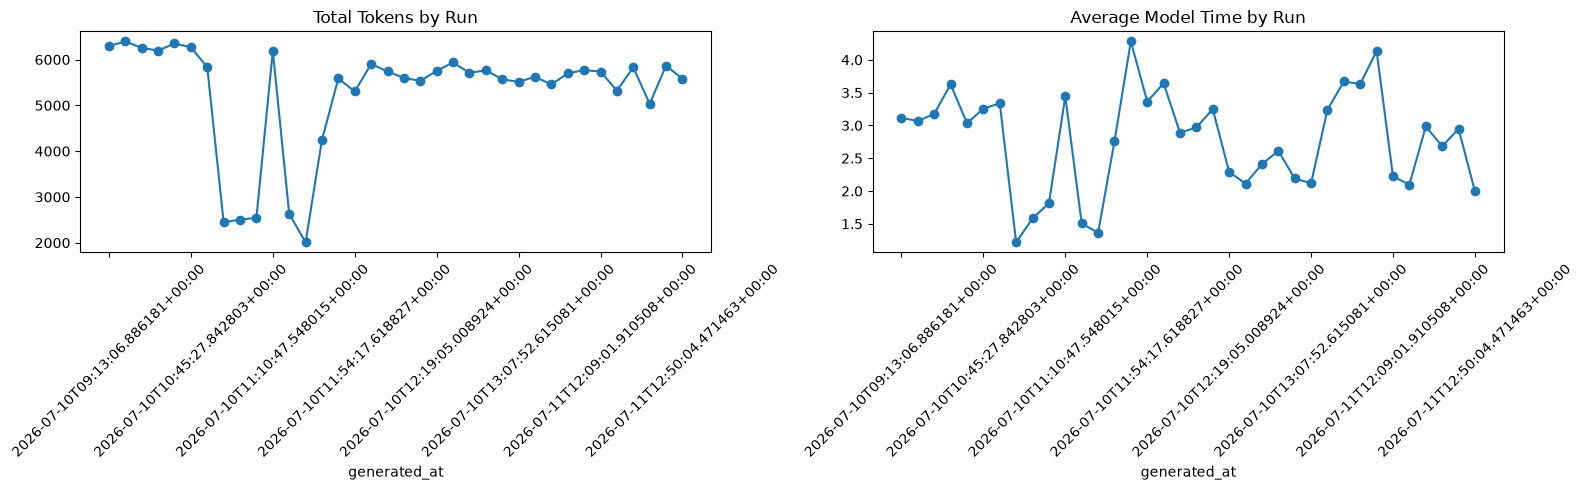

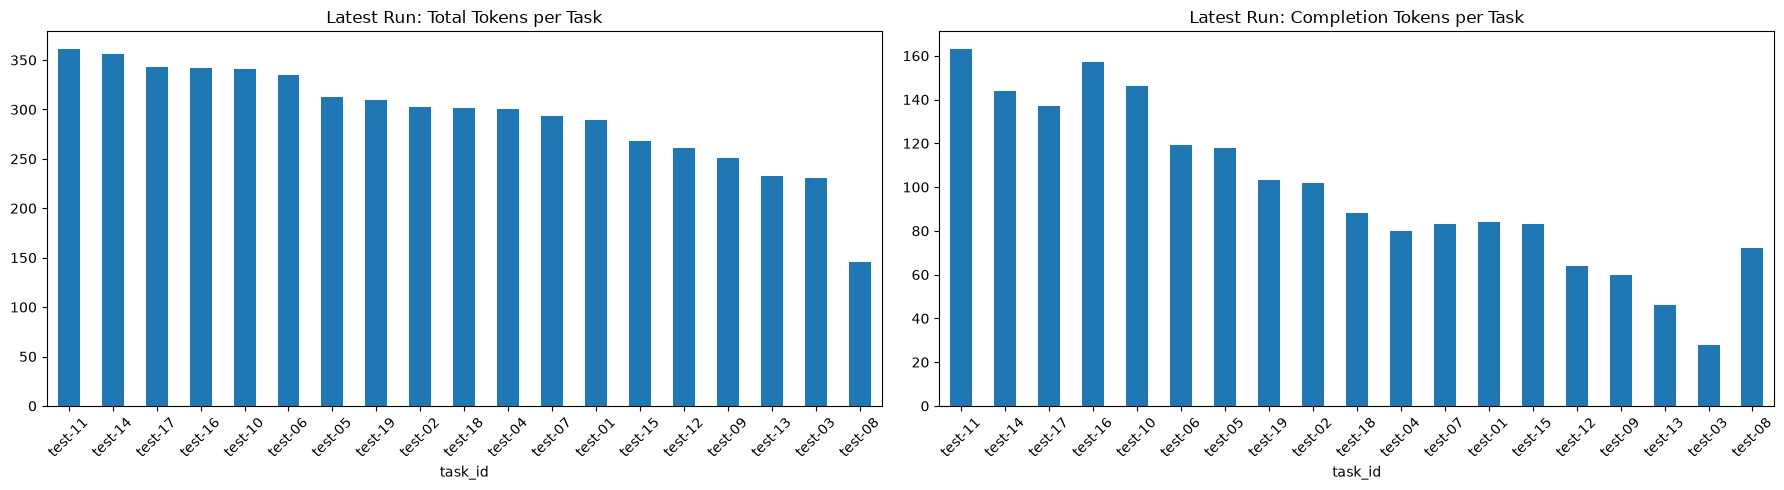

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

run_history.plot(x="generated_at", y="total_tokens", ax=axes[0], marker="o", legend=False, title="Total Tokens by Run")
run_history.plot(x="generated_at", y="average_model_elapsed_seconds", ax=axes[1], marker="o", legend=False, title="Average Model Time by Run")

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

latest_tasks.sort_values("total_tokens", ascending=False).plot.bar(
    x="task_id",
    y="total_tokens",
    ax=axes[0],
    legend=False,
    title="Latest Run: Total Tokens per Task",
)

latest_tasks.sort_values("total_tokens", ascending=False).plot.bar(
    x="task_id",
    y="completion_tokens",
    ax=axes[1],
    legend=False,
    title="Latest Run: Completion Tokens per Task",
)

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Latest run:


,latest
tasks,19
total_tokens,5576
prompt_tokens,3699
completion_tokens,1877
pipeline_elapsed_seconds,57.5075
average_model_elapsed_seconds,1.9958
generated_at,2026-07-11T12:50:04.471463+00:00
history_file,run_c8bc8cd03d7f4f9390f13c8809119b5b.json
run_id,c8bc8cd03d7f4f9390f13c8809119b5b


Previous run:


,previous
tasks,19
total_tokens,5869
prompt_tokens,3371
completion_tokens,2498
pipeline_elapsed_seconds,81.4698
average_model_elapsed_seconds,2.9488
generated_at,2026-07-11T12:43:24.046368+00:00
history_file,run_3826c64f14be4a1abdb785dd6bb974ea.json
run_id,3826c64f14be4a1abdb785dd6bb974ea


Run comparison:


,latest,previous,delta
total_tokens,5576,5869,-293
prompt_tokens,3699,3371,328
completion_tokens,1877,2498,-621
pipeline_elapsed_seconds,57.5075,81.4698,-23.9623
average_model_elapsed_seconds,1.9958,2.9488,-0.953


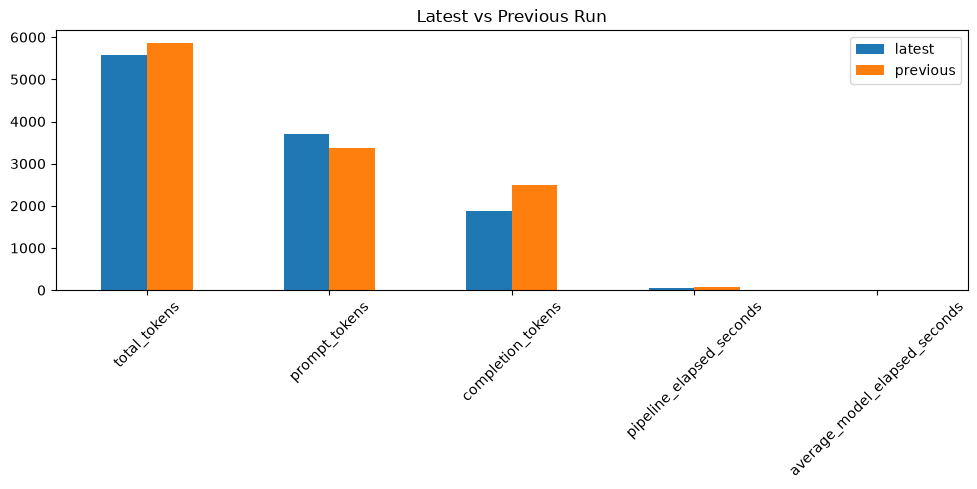

Latest task breakdown:


,task_id,category,confidence,method,router_model,router_prompt_tokens,router_completion_tokens,router_total_tokens,chosen_model,reason,allocated_tokens,prompt_tokens,completion_tokens,total_tokens,completion_efficiency,model_elapsed_seconds
10,test-11,factual_knowledge,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_factual_knowledge_fast_efficient,394,198,163,361,0.414,2.1613
13,test-14,factual_knowledge,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_factual_knowledge_fast_efficient,144,212,144,356,1.000,6.7961
16,test-17,factual_knowledge,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_factual_knowledge_fast_efficient,398,206,137,343,0.344,1.7118
15,test-16,text_summarisation,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_text_summarisation_fast_effic...,361,185,157,342,0.435,2.1583
9,test-10,text_summarisation,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_text_summarisation_fast_effic...,369,195,146,341,0.396,2.0027
5,test-06,factual_knowledge,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_factual_knowledge_fast_efficient,347,216,119,335,0.343,1.6462
4,test-05,named_entity_recognition,0.90,rules,NaN,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_named_entity_recognition_fast...,182,195,118,313,0.648,1.5795
18,test-19,factual_knowledge,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_factual_knowledge_fast_efficient,343,207,103,310,0.300,1.4796
1,test-02,text_summarisation,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_text_summarisation_fast_effic...,370,200,102,302,0.276,1.6152
17,test-18,factual_knowledge,1.00,ai_router,accounts/fireworks/models/minimax-m3,0,0,0,accounts/fireworks/models/minimax-m3,capability_match_factual_knowledge_fast_efficient,351,213,88,301,0.251,1.6975


In [15]:
compare_cols = [
    "tasks",
    "total_tokens",
    "prompt_tokens",
    "completion_tokens",
    "pipeline_elapsed_seconds",
    "average_model_elapsed_seconds",
    "generated_at",
    "history_file",
    "run_id",
]

print("Latest run:")
display(latest_run[compare_cols].to_frame(name="latest"))

if previous_run is not None:
    print("Previous run:")
    display(previous_run[compare_cols].to_frame(name="previous"))

    comparison = pd.DataFrame({
        "latest": latest_run[["total_tokens", "prompt_tokens", "completion_tokens", "pipeline_elapsed_seconds", "average_model_elapsed_seconds"]],
        "previous": previous_run[["total_tokens", "prompt_tokens", "completion_tokens", "pipeline_elapsed_seconds", "average_model_elapsed_seconds"]],
    })
    comparison["delta"] = comparison["latest"] - comparison["previous"]
    print("Run comparison:")
    display(comparison)

    fig, ax = plt.subplots(figsize=(10, 5))
    comparison[["latest", "previous"]].plot.bar(ax=ax, title="Latest vs Previous Run")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Only one run is available, so there is no previous run to compare.")

print("Latest task breakdown:")
display(latest_tasks.sort_values("total_tokens", ascending=False))